# 🔬 Notebook 03: NLP Preprocessing & Feature Engineering Pipeline
## Master Thesis: AI-Powered ATS with Deep Learning, Credibility Verification & Explainable AI

**Author:** Hitik Sharma  
**Date:** 2026  

---

### Objective
This notebook implements the **complete NLP preprocessing pipeline** that transforms raw resume and job description text into model-ready features. Our pipeline is grounded in methodologies from the reference papers:

| Step | Method | Paper Reference |
|------|--------|-----------------|
| Text Cleaning | HTML removal, regex normalization | Paper 1 (NLP+LSTM), Paper 3 (Regex Parser) |
| Entity Extraction | Regex + spaCy NER | Paper 3, Paper 5 (SATYA) |
| Section Segmentation | Rule-based section detection | Paper 5 (SATYA) |
| Skill Extraction | Taxonomy matching + NLP | Paper 8 (Skill Similarity), Paper 5 |
| Tokenization & Vectorization | TF-IDF + Word2Vec | Paper 1, Paper 3, Paper 8 |
| Sentence Embeddings | SBERT (all-MiniLM-L6-v2) | Paper 5 |
| Label Encoding | One-hot + LabelEncoder | Paper 1, Paper 3 |

### Scientific Contribution
> Paper 5 (SATYA) uses *"spaCy and BERT to parse and tokenize resumes, extracting relevant sections such as Education, Work Experience, and Skills."* Paper 3 uses regex for entity extraction achieving 98.29% accuracy. Paper 1 describes a pipeline: *"cleaning → stopword removal → tokenization → vectorization → model training."* Our pipeline **unifies and extends** all these approaches into a single, reproducible pipeline.

---

In [3]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import os
import sys
import re
import json
import glob
import string
import pickle
import warnings
from collections import Counter
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

import spacy

# Scikit-learn for vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# NLTK downloads
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# ---- Paths ----
PROJECT_ROOT = os.path.expanduser("~/Desktop/thesis_final")
DATA_RAW = os.path.join(PROJECT_ROOT, "data/raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data/processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "reports/figures")
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Thesis plot styling
plt.rcParams.update({'figure.figsize': (12,6), 'font.size': 12, 'figure.dpi': 150, 'savefig.dpi': 300})
PALETTE = ['#3498DB','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C','#E67E22','#2980B9']

def save_fig(fig, name):
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.png"), dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 Saved: {name}.png")

print(f"✅ All imports ready!")
print(f"📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔤 spaCy model: {nlp.meta['name']} v{nlp.meta['version']}")

✅ All imports ready!
📅 2026-04-21 09:58:44
🔤 spaCy model: core_web_sm v3.8.0


---
## 1. Load Datasets

In [4]:
# ============================================================
# 1.1 Load Resume Corpus
# ============================================================

df_resumes = pd.read_csv(os.path.join(DATA_RAW, "resumes/UpdatedResumeDataSet.csv"))
print(f"✅ Resume Corpus: {df_resumes.shape}")
print(f"   Categories: {df_resumes['Category'].nunique()}")

# Load Job Descriptions (sample for speed)
jd_path = os.path.join(DATA_RAW, "job_descriptions/job_descriptions.csv")
if os.path.exists(jd_path):
    df_jd = pd.read_csv(jd_path, nrows=30000, low_memory=False)
    print(f"✅ Job Descriptions: {df_jd.shape}")
else:
    df_jd = pd.read_csv(os.path.join(DATA_RAW, "job_descriptions/job_title_des.csv"))
    print(f"✅ Job Descriptions (small): {df_jd.shape}")

# Load Skills Taxonomy
skills_path = os.path.join(DATA_PROCESSED, "skills_taxonomy.json")
if os.path.exists(skills_path):
    with open(skills_path, 'r') as f:
        skills_taxonomy = json.load(f)
    all_skills = [s for cat_skills in skills_taxonomy.values() for s in cat_skills]
    skill_to_cat = {s: cat for cat, skills in skills_taxonomy.items() for s in skills}
    print(f"✅ Skills Taxonomy: {len(all_skills)} skills in {len(skills_taxonomy)} categories")
else:
    print("⚠️ Run Notebook 01 first to create skills_taxonomy.json")

✅ Resume Corpus: (962, 2)
   Categories: 25
✅ Job Descriptions: (30000, 23)
✅ Skills Taxonomy: 206 skills in 11 categories


---
## 2. Text Cleaning Pipeline

Based on Paper 1 methodology: *"The input text should be cleaned — free of unnecessary words, links, or details. We remove stopwords, Hashtags, URLs using regular expressions."*

And Paper 3: *"The extracted text is preprocessed — lowercasing, tokenization, removal of stop words and punctuation."*

In [5]:
# ============================================================
# 2.1 Define Comprehensive Text Cleaning Functions
# ============================================================

def clean_resume_text(text):
    """
    Comprehensive resume text cleaning pipeline.
    Based on Paper 1 (NLP+LSTM) and Paper 3 (Regex Parser) methodology.
    
    Steps:
    1. Remove HTML tags
    2. Remove URLs
    3. Remove email addresses (store separately)
    4. Remove phone numbers (store separately)
    5. Remove special characters and extra whitespace
    6. Normalize unicode characters
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Step 1: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    
    # Step 3: Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    
    # Step 4: Remove phone numbers (various formats)
    text = re.sub(r'[\+]?[(]?[0-9]{1,4}[)]?[-\s\./0-9]{7,15}', ' ', text)
    
    # Step 5: Remove special characters (keep letters, numbers, basic punctuation)
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\;\:\-\/\+\#]', ' ', text)
    
    # Step 6: Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


def normalize_text(text):
    """
    Advanced text normalization for NLP processing.
    """
    if not text:
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove numbers (optional — keep for experience years)
    # text = re.sub(r'\d+', '', text)
    
    # Remove extra punctuation but keep meaningful ones
    text = re.sub(r'[^a-z0-9\s\+\#\.]', ' ', text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


print("✅ Cleaning functions defined")

# Test on a sample
sample = df_resumes['Resume'].iloc[0]
cleaned = clean_resume_text(sample)
print(f"\n📝 Original (first 200 chars): {sample[:200]}")
print(f"\n📝 Cleaned (first 200 chars):  {cleaned[:200]}")

✅ Cleaning functions defined

📝 Original (first 200 chars): Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision T

📝 Cleaned (first 200 chars):  Skills Programming Languages: Python pandas, numpy, scipy, scikit-learn, matplotlib , Sql, Java, JavaScript/JQuery. Machine learning: Regression, SVM, Na ve Bayes, KNN, Random Forest, Decision Trees, 


In [6]:
# ============================================================
# 2.2 Apply Cleaning to Full Resume Dataset
# ============================================================

print("⏳ Cleaning all resumes...")
df_resumes['cleaned_text'] = df_resumes['Resume'].apply(clean_resume_text)
df_resumes['normalized_text'] = df_resumes['cleaned_text'].apply(normalize_text)

# Stats
df_resumes['clean_word_count'] = df_resumes['cleaned_text'].str.split().str.len()
df_resumes['clean_char_count'] = df_resumes['cleaned_text'].str.len()

print(f"✅ Cleaning complete!")
print(f"\n📊 Before vs After Cleaning:")
orig_len = df_resumes['Resume'].str.len().mean()
clean_len = df_resumes['cleaned_text'].str.len().mean()
print(f"  Avg char length: {orig_len:.0f} → {clean_len:.0f} ({(1-clean_len/orig_len)*100:.1f}% reduction)")
print(f"  Avg word count:  {df_resumes['clean_word_count'].mean():.0f}")
print(f"  Empty resumes:   {(df_resumes['clean_word_count'] < 10).sum()}")

⏳ Cleaning all resumes...
✅ Cleaning complete!

📊 Before vs After Cleaning:
  Avg char length: 3160 → 2998 (5.1% reduction)
  Avg word count:  430
  Empty resumes:   0


---
## 3. Regex-Based Entity Extraction

Based on Paper 3 (Intelligent Resume Parser): *"Regular expressions are utilized to extract details such as name, email, mobile number, education details and skills."*

And Paper 10 (Regex-based extraction).

In [7]:
# ============================================================
# 3.1 Regex Entity Extraction Functions
# (Based on Paper 3 Fig.1 regex patterns)
# ============================================================

def extract_email(text):
    """Extract email addresses from text."""
    pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    emails = re.findall(pattern, str(text))
    return emails[0] if emails else None

def extract_phone(text):
    """Extract phone numbers from text."""
    pattern = r'[\+]?[(]?[0-9]{1,4}[)]?[-\s\./0-9]{7,15}'
    phones = re.findall(pattern, str(text))
    # Filter out likely non-phone numbers (too short)
    phones = [p.strip() for p in phones if len(re.sub(r'\D', '', p)) >= 10]
    return phones[0] if phones else None

def extract_name_spacy(text):
    """Extract person name using spaCy NER."""
    doc = nlp(str(text)[:500])  # First 500 chars usually contain name
    for ent in doc.ents:
        if ent.label_ == 'PERSON':
            return ent.text
    return None

def extract_education(text):
    """
    Extract education level from resume text.
    Based on Paper 3 methodology — maps to Bachelor's or Master's.
    """
    text_lower = str(text).lower()
    
    education_patterns = {
        'PhD': r'\b(ph\.?d|doctor(?:ate)?|d\.?phil)\b',
        'Masters': r'\b(master(?:s|\'s)?|m\.?s\.?|m\.?sc|m\.?tech|m\.?eng|mba|m\.?a\.?)\b',
        'Bachelors': r'\b(bachelor(?:s|\'s)?|b\.?s\.?|b\.?sc|b\.?tech|b\.?eng|b\.?a\.?|b\.?com)\b',
        'Diploma': r'\b(diploma|associate(?:s|\'s)?)\b',
        'High School': r'\b(high school|secondary|hsc|ssc|12th|10th)\b',
    }
    
    found = []
    for level, pattern in education_patterns.items():
        if re.search(pattern, text_lower):
            found.append(level)
    
    return found if found else ['Unknown']

def extract_years_experience(text):
    """
    Extract years of experience from text.
    """
    text_lower = str(text).lower()
    
    patterns = [
        r'(\d+)\+?\s*(?:years?|yrs?)\s*(?:of)?\s*(?:experience|exp)',
        r'(?:experience|exp)\s*(?:of)?\s*(\d+)\+?\s*(?:years?|yrs?)',
        r'(\d+)\+?\s*(?:years?|yrs?)\s*(?:in|of|working)',
    ]
    
    years = []
    for pattern in patterns:
        matches = re.findall(pattern, text_lower)
        years.extend([int(m) for m in matches if int(m) <= 50])  # sanity check
    
    return max(years) if years else None

def extract_links(text):
    """Extract LinkedIn and GitHub URLs."""
    text_str = str(text)
    linkedin = re.findall(r'(?:https?://)?(?:www\.)?linkedin\.com/in/[\w-]+', text_str)
    github = re.findall(r'(?:https?://)?(?:www\.)?github\.com/[\w-]+', text_str)
    return {'linkedin': linkedin[0] if linkedin else None,
            'github': github[0] if github else None}

print("✅ Entity extraction functions defined")

✅ Entity extraction functions defined


In [8]:
# ============================================================
# 3.2 Apply Entity Extraction to All Resumes
# ============================================================

print("⏳ Extracting entities from resumes (this takes ~2-3 minutes)...")

# Use original text for entity extraction (before cleaning removes emails/phones)
raw_text = df_resumes['Resume']

df_resumes['email'] = raw_text.apply(extract_email)
print("  ✅ Emails extracted")

df_resumes['phone'] = raw_text.apply(extract_phone)
print("  ✅ Phone numbers extracted")

df_resumes['education_level'] = raw_text.apply(extract_education)
df_resumes['highest_education'] = df_resumes['education_level'].apply(lambda x: x[0])
print("  ✅ Education levels extracted")

df_resumes['years_exp'] = raw_text.apply(extract_years_experience)
print("  ✅ Years of experience extracted")

links = raw_text.apply(extract_links)
df_resumes['linkedin'] = links.apply(lambda x: x['linkedin'])
df_resumes['github'] = links.apply(lambda x: x['github'])
print("  ✅ LinkedIn/GitHub links extracted")

# Summary
print(f"\n{'='*50}")
print(f"📊 ENTITY EXTRACTION SUMMARY")
print(f"{'='*50}")
print(f"Emails found:    {df_resumes['email'].notna().sum():,} / {len(df_resumes):,} ({df_resumes['email'].notna().mean()*100:.1f}%)")
print(f"Phones found:    {df_resumes['phone'].notna().sum():,} / {len(df_resumes):,} ({df_resumes['phone'].notna().mean()*100:.1f}%)")
print(f"LinkedIn found:  {df_resumes['linkedin'].notna().sum():,}")
print(f"GitHub found:    {df_resumes['github'].notna().sum():,}")
print(f"Exp. years found:{df_resumes['years_exp'].notna().sum():,}")
print(f"\n📋 Education Level Distribution:")
print(df_resumes['highest_education'].value_counts())

⏳ Extracting entities from resumes (this takes ~2-3 minutes)...
  ✅ Emails extracted
  ✅ Phone numbers extracted
  ✅ Education levels extracted
  ✅ Years of experience extracted
  ✅ LinkedIn/GitHub links extracted

📊 ENTITY EXTRACTION SUMMARY
Emails found:    4 / 962 (0.4%)
Phones found:    28 / 962 (2.9%)
LinkedIn found:  4
GitHub found:    4
Exp. years found:95

📋 Education Level Distribution:
highest_education
Masters        399
Bachelors      196
Unknown        157
Diploma        131
High School     64
PhD             15
Name: count, dtype: int64


---
## 4. Resume Section Segmentation

Based on Paper 5 (SATYA): *"spaCy and BERT to parse and tokenize resumes, extracting relevant sections such as Education, Work Experience, and Skills. Special attention is given to handling irregular formats."*

In [9]:
# ============================================================
# 4.1 Resume Section Segmentation
# ============================================================

SECTION_HEADERS = {
    'education': [
        r'\b(education|academic|qualification|degree|university|college|school|certif)\b'
    ],
    'experience': [
        r'\b(experience|employment|work\s*history|professional|career|position|job)\b'
    ],
    'skills': [
        r'\b(skill|technical|competenc|proficienc|expertise|technolog|tool|language)\b'
    ],
    'projects': [
        r'\b(project|portfolio|assignment|capstone|thesis)\b'
    ],
    'summary': [
        r'\b(summary|objective|profile|about|overview|introduction)\b'
    ],
    'achievements': [
        r'\b(achievement|award|honor|recognition|publication|accomplishment)\b'
    ],
}

def segment_resume(text):
    """
    Segment resume into sections based on header detection.
    Returns dict of {section_name: section_text}.
    """
    if pd.isna(text) or not text:
        return {sec: '' for sec in SECTION_HEADERS}
    
    text = str(text)
    lines = text.split('\n') if '\n' in text else re.split(r'(?<=[.!?])\s+', text)
    
    sections = {sec: [] for sec in SECTION_HEADERS}
    sections['other'] = []
    current_section = 'other'
    
    for line in lines:
        line_lower = line.strip().lower()
        
        # Check if this line is a section header
        header_found = False
        for section, patterns in SECTION_HEADERS.items():
            for pattern in patterns:
                if re.search(pattern, line_lower) and len(line.split()) <= 6:
                    current_section = section
                    header_found = True
                    break
            if header_found:
                break
        
        if not header_found and line.strip():
            sections[current_section].append(line.strip())
    
    return {sec: ' '.join(lines) for sec, lines in sections.items()}

# Apply to resumes
print("⏳ Segmenting resumes into sections...")
sections_data = df_resumes['cleaned_text'].apply(segment_resume)

for section in list(SECTION_HEADERS.keys()) + ['other']:
    df_resumes[f'section_{section}'] = sections_data.apply(lambda x: x.get(section, ''))

# Check section coverage
print(f"\n📊 Section Coverage:")
for section in SECTION_HEADERS:
    non_empty = (df_resumes[f'section_{section}'].str.len() > 10).sum()
    print(f"  {section:15s}: {non_empty:>5,} resumes ({non_empty/len(df_resumes)*100:.1f}%)")

⏳ Segmenting resumes into sections...

📊 Section Coverage:
  education      :    77 resumes (8.0%)
  experience     :    60 resumes (6.2%)
  skills         :    36 resumes (3.7%)
  projects       :    87 resumes (9.0%)
  summary        :     8 resumes (0.8%)
  achievements   :     0 resumes (0.0%)


---
## 5. Advanced Skill Extraction

Paper 8: *"A crucial aspect of preprocessing involves honing in on skill extraction, recognizing the pivotal role that skills play in determining a candidate's suitability for a particular job."*

In [10]:
# ============================================================
# 5.1 Advanced Skill Extraction with Context
# ============================================================

def extract_skills_advanced(text, skills_list, skill_to_category):
    """
    Extract skills with context awareness.
    Returns list of dicts with skill name, category, and context.
    """
    if pd.isna(text) or not text:
        return []
    
    text_lower = str(text).lower()
    found_skills = []
    
    for skill in skills_list:
        skill_lower = skill.lower()
        # Use word boundary for short skills to avoid false positives
        if len(skill_lower) <= 3:
            pattern = r'\b' + re.escape(skill_lower) + r'\b'
        else:
            pattern = re.escape(skill_lower)
        
        matches = list(re.finditer(pattern, text_lower))
        if matches:
            # Get context (surrounding words)
            match = matches[0]
            start = max(0, match.start() - 50)
            end = min(len(text_lower), match.end() + 50)
            context = text_lower[start:end].strip()
            
            found_skills.append({
                'skill': skill,
                'category': skill_to_category.get(skill, 'unknown'),
                'count': len(matches),
                'context': context
            })
    
    return found_skills

# Apply
print("⏳ Extracting skills with context (this may take 1-2 minutes)...")
df_resumes['skills_detailed'] = df_resumes['cleaned_text'].apply(
    lambda x: extract_skills_advanced(x, all_skills, skill_to_cat)
)

# Extract simple skill lists and counts
df_resumes['skills_list'] = df_resumes['skills_detailed'].apply(
    lambda x: [s['skill'] for s in x]
)
df_resumes['skill_count'] = df_resumes['skills_list'].str.len()
df_resumes['skill_categories'] = df_resumes['skills_detailed'].apply(
    lambda x: list(set(s['category'] for s in x))
)

print(f"\n✅ Skill extraction complete!")
print(f"Average skills per resume: {df_resumes['skill_count'].mean():.1f}")
print(f"Median skills per resume:  {df_resumes['skill_count'].median():.0f}")
print(f"Max skills in a resume:    {df_resumes['skill_count'].max()}")

⏳ Extracting skills with context (this may take 1-2 minutes)...

✅ Skill extraction complete!
Average skills per resume: 5.7
Median skills per resume:  5
Max skills in a resume:    30


💾 Saved: fig_18_avg_skills_per_category.png


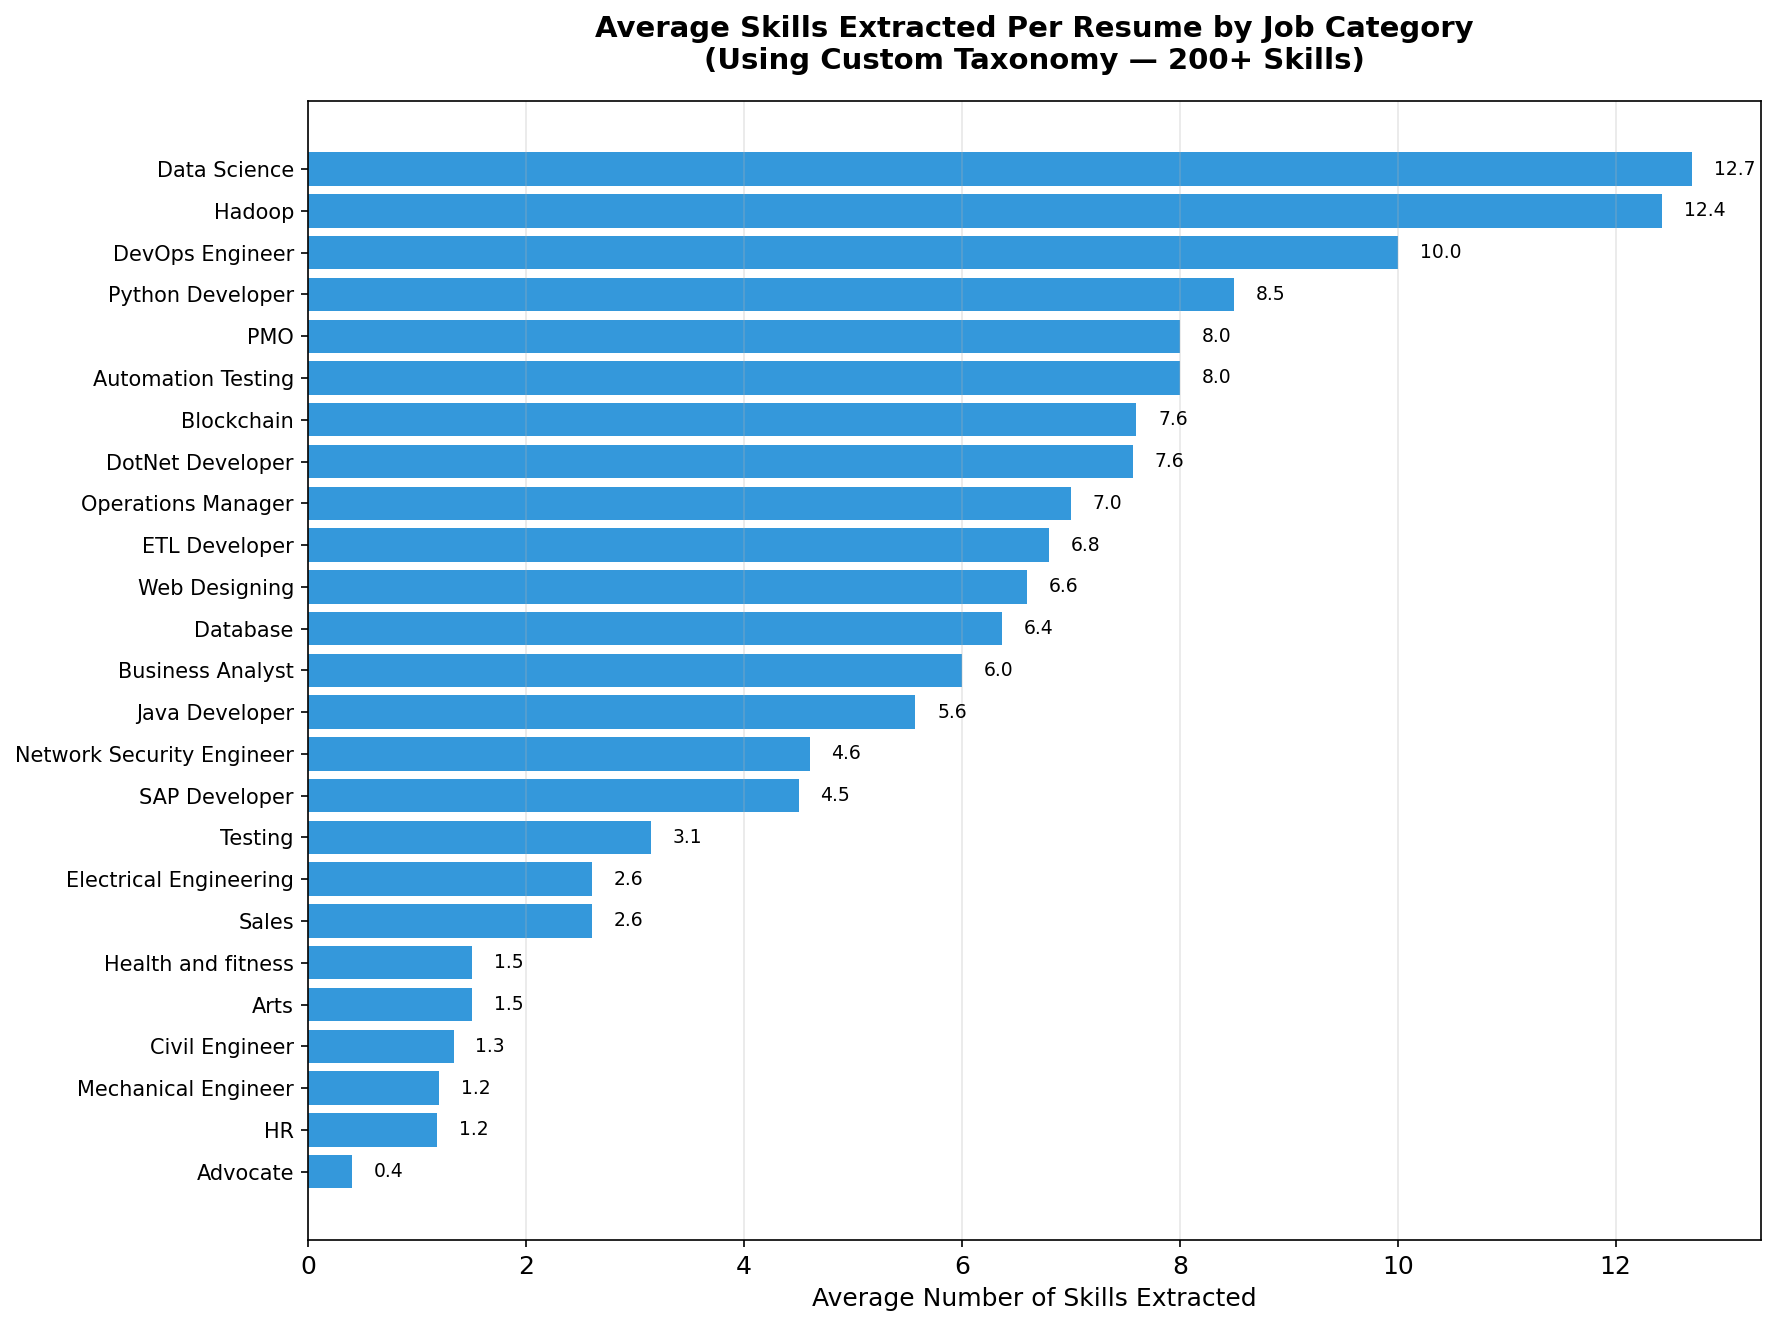

In [11]:
# ============================================================
# 5.2 FIGURE: Average Skills Per Category
# ============================================================

avg_skills_by_cat = df_resumes.groupby('Category')['skill_count'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(range(len(avg_skills_by_cat)), avg_skills_by_cat.values, color=PALETTE[0])
ax.set_yticks(range(len(avg_skills_by_cat)))
ax.set_yticklabels(avg_skills_by_cat.index, fontsize=10)
ax.set_xlabel('Average Number of Skills Extracted', fontsize=12)
ax.set_title('Average Skills Extracted Per Resume by Job Category\n(Using Custom Taxonomy — 200+ Skills)',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

for i, val in enumerate(avg_skills_by_cat.values):
    ax.text(val + 0.2, i, f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
save_fig(fig, 'fig_18_avg_skills_per_category')
plt.show()

---
## 6. Tokenization & Stopword Removal

Paper 1: *"After the resume is cleaned, the input text undergoes a tokenization process. Tokenization is the process of dividing the sentences into words known as tokens."*

In [12]:
# ============================================================
# 6.1 Tokenization, Stopword Removal & Lemmatization
# ============================================================

stop_words = set(stopwords.words('english'))
# Add domain-specific stopwords
stop_words.update(['resume', 'curriculum', 'vitae', 'cv', 'name', 'address',
                   'phone', 'email', 'objective', 'reference', 'available',
                   'upon', 'request', 'etc', 'also', 'would', 'could'])

lemmatizer = WordNetLemmatizer()

def preprocess_for_nlp(text):
    """
    Full NLP preprocessing: tokenize → lowercase → remove stopwords → lemmatize.
    Returns both the token list and the processed string.
    """
    if not text:
        return [], ""
    
    # Tokenize
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords, punctuation, and short tokens
    tokens = [t for t in tokens if t not in stop_words 
              and t not in string.punctuation 
              and len(t) > 2
              and t.isalpha()]
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return tokens, ' '.join(tokens)

print("⏳ Tokenizing and lemmatizing all resumes...")
results = df_resumes['cleaned_text'].apply(preprocess_for_nlp)
df_resumes['tokens'] = results.apply(lambda x: x[0])
df_resumes['processed_text'] = results.apply(lambda x: x[1])
df_resumes['token_count'] = df_resumes['tokens'].str.len()

print(f"\n✅ Tokenization complete!")
print(f"Average tokens per resume: {df_resumes['token_count'].mean():.0f}")
print(f"\n📝 Sample processed text (first 200 chars):")
print(df_resumes['processed_text'].iloc[0][:200])

⏳ Tokenizing and lemmatizing all resumes...

✅ Tokenization complete!
Average tokens per resume: 290

📝 Sample processed text (first 200 chars):
skill programming language python panda numpy scipy matplotlib sql java machine learning regression svm bayes knn random forest decision tree boosting technique cluster analysis word embedding sentime


---
## 7. TF-IDF Vectorization

Paper 3: *"TF-IDF vectorization is applied separately to both education details and skills, and the resulting TF-IDF vectors are concatenated to form a new dataset."*

Paper 1: *"In Vectorization, each word or token is mapped with a corresponding vector. The input text is in the form of vectors given as input to the trained model."*

In [13]:
# ============================================================
# 7.1 TF-IDF Vectorization
# ============================================================

# Full resume TF-IDF
print("⏳ Building TF-IDF vectors...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Top 5000 features
    min_df=5,               # Appear in at least 5 documents
    max_df=0.95,            # Appear in at most 95% of documents
    ngram_range=(1, 2),     # Unigrams and bigrams
    sublinear_tf=True,      # Apply sublinear TF scaling
    stop_words='english'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_resumes['processed_text'])

print(f"\n✅ TF-IDF Vectorization complete!")
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Features: {tfidf_matrix.shape[1]:,}")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))*100:.2f}%")

# Top features
feature_names = tfidf_vectorizer.get_feature_names_out()
avg_tfidf = tfidf_matrix.mean(axis=0).A1
top_features_idx = avg_tfidf.argsort()[-20:][::-1]
print(f"\n📋 Top 20 TF-IDF Features:")
for idx in top_features_idx:
    print(f"  {feature_names[idx]:25s} — avg TF-IDF: {avg_tfidf[idx]:.4f}")

⏳ Building TF-IDF vectors...

✅ TF-IDF Vectorization complete!
Matrix shape: (962, 5000)
Features: 5,000
Sparsity: 96.39%

📋 Top 20 TF-IDF Features:
  exprience                 — avg TF-IDF: 0.0426
  month                     — avg TF-IDF: 0.0391
  exprience month           — avg TF-IDF: 0.0330
  month exprience           — avg TF-IDF: 0.0323
  january                   — avg TF-IDF: 0.0297
  project                   — avg TF-IDF: 0.0295
  year                      — avg TF-IDF: 0.0291
  maharashtra               — avg TF-IDF: 0.0288
  exprience year            — avg TF-IDF: 0.0269
  developer                 — avg TF-IDF: 0.0265
  technology                — avg TF-IDF: 0.0240
  engineering               — avg TF-IDF: 0.0233
  data                      — avg TF-IDF: 0.0228
  pune                      — avg TF-IDF: 0.0228
  education                 — avg TF-IDF: 0.0226
  college                   — avg TF-IDF: 0.0222
  java                      — avg TF-IDF: 0.0221
  university      

💾 Saved: fig_19_tfidf_top_features_by_category.png


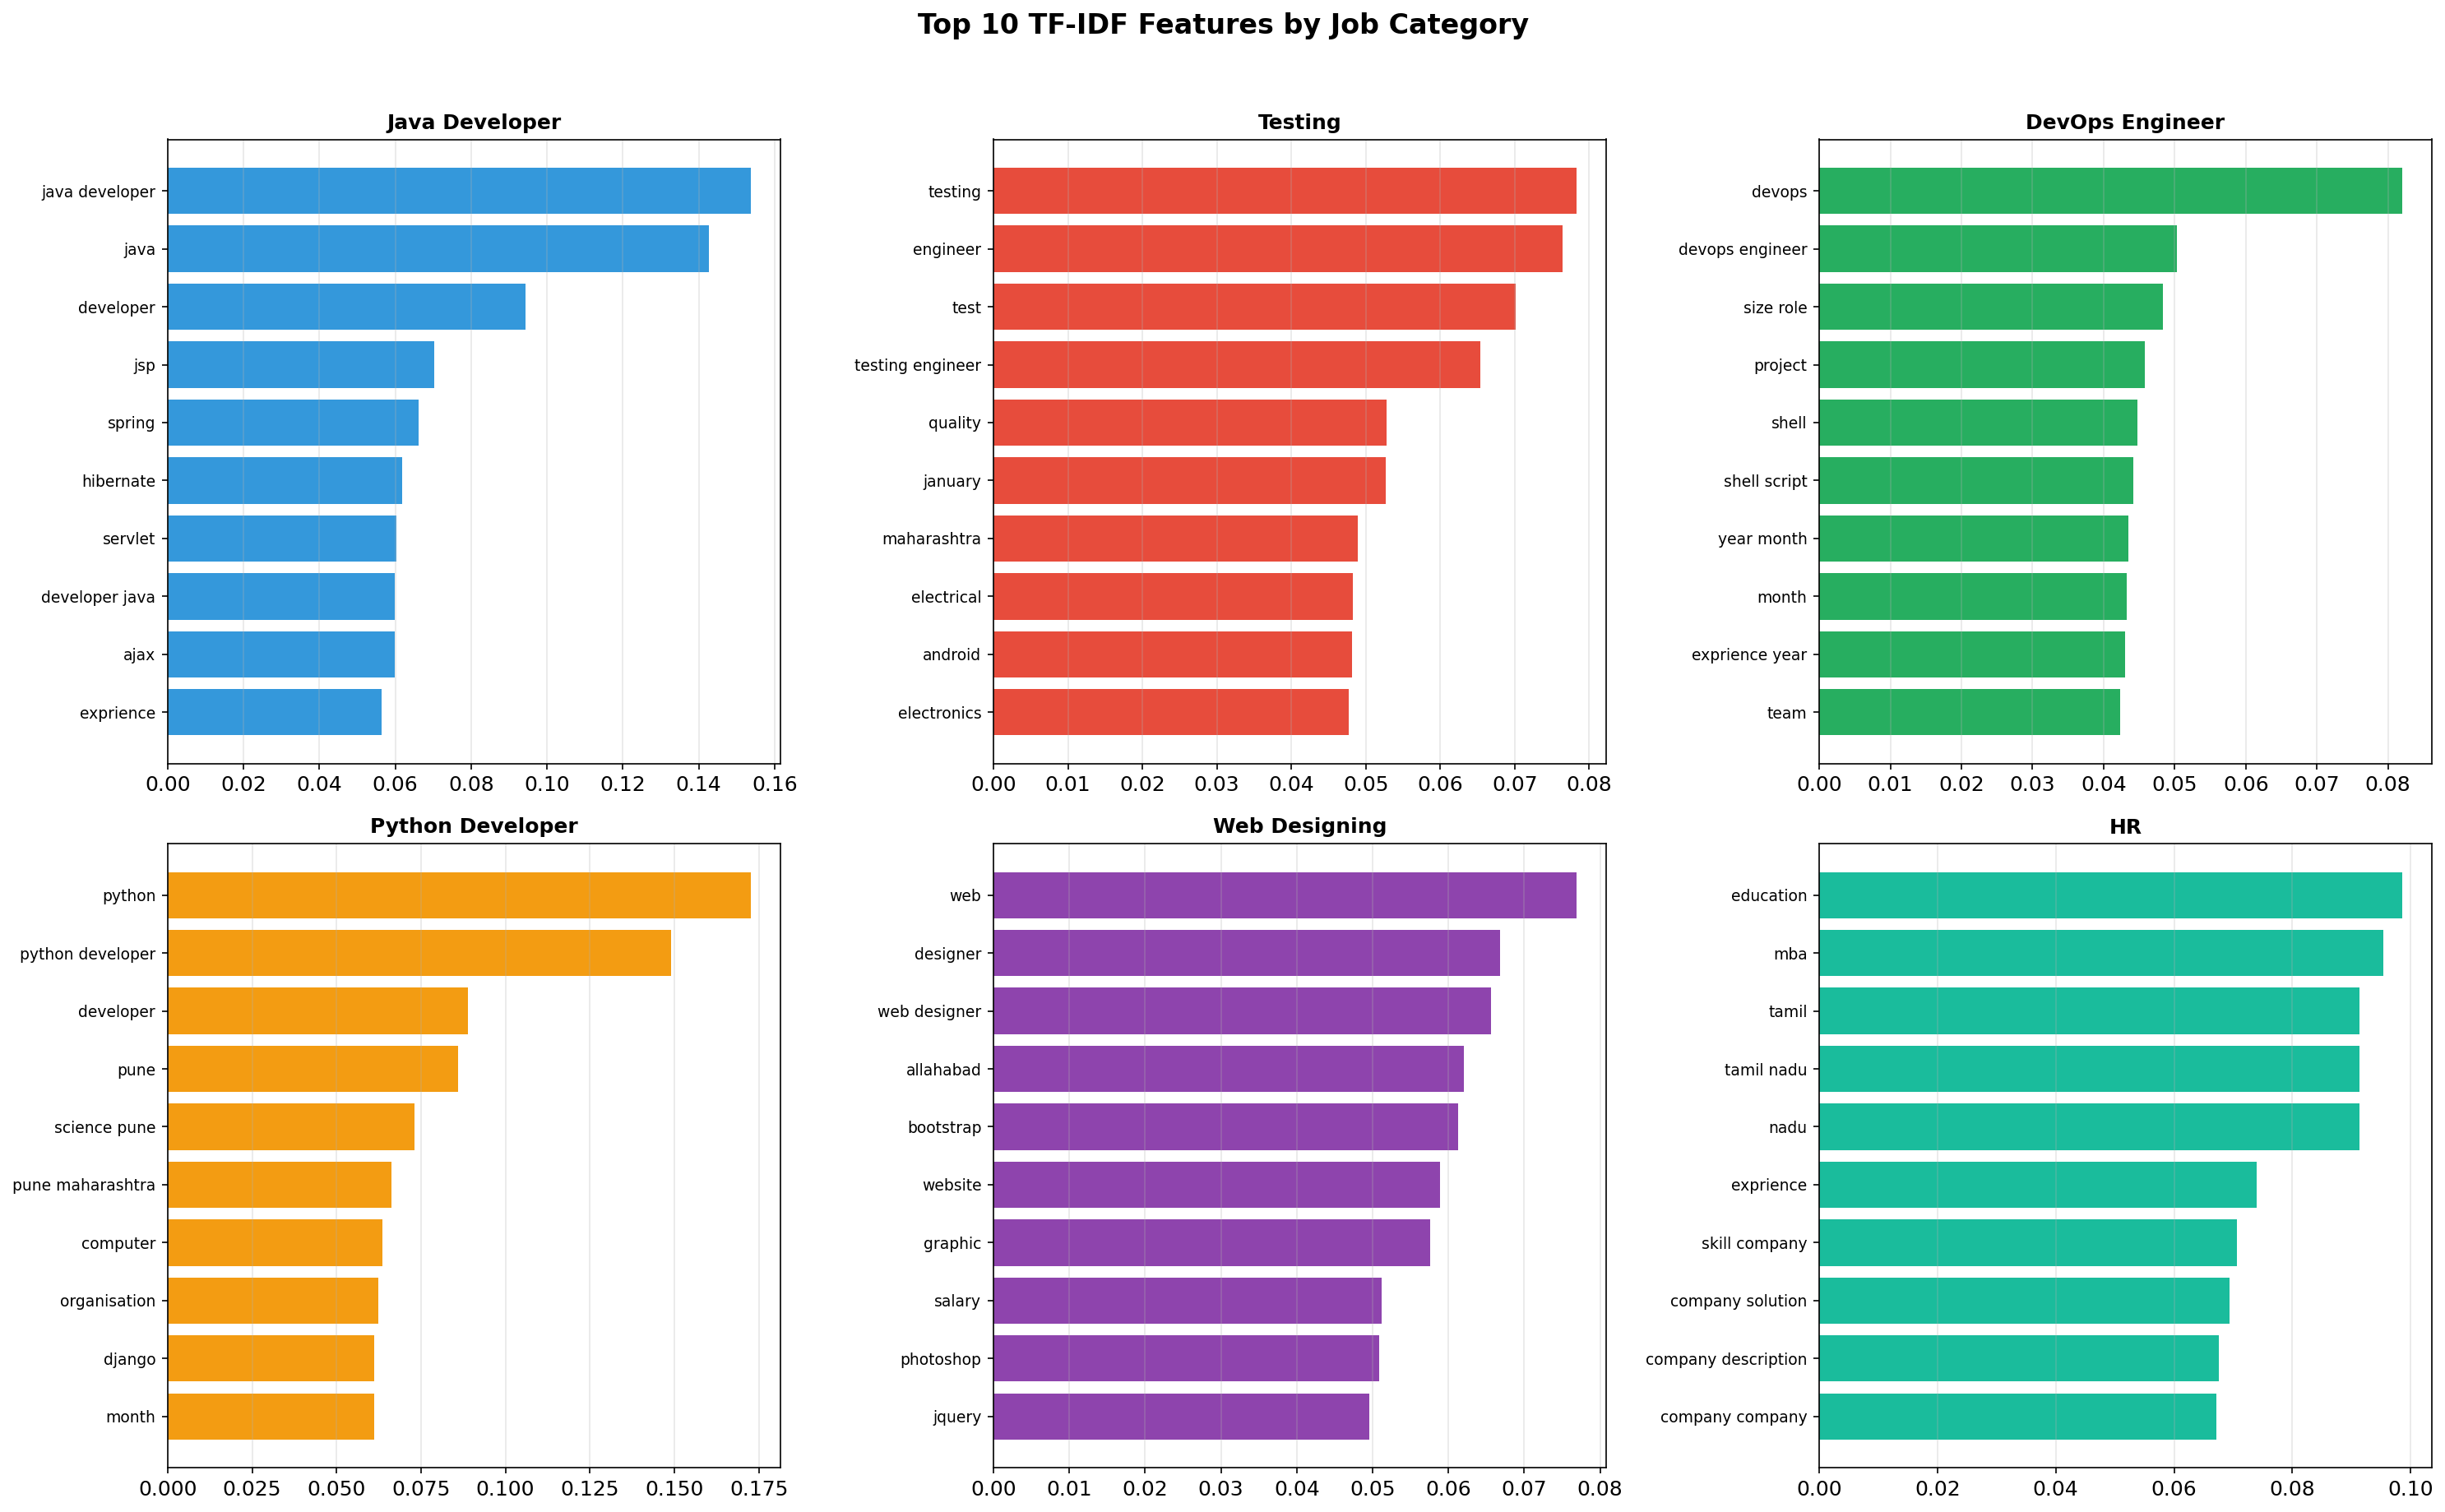

In [14]:
# ============================================================
# 7.2 FIGURE: Top TF-IDF Features by Category
# ============================================================

top_categories = df_resumes['Category'].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Top 10 TF-IDF Features by Job Category', fontsize=16, fontweight='bold', y=1.02)

for idx, (cat, ax) in enumerate(zip(top_categories, axes.flatten())):
    cat_mask = df_resumes['Category'] == cat
    cat_tfidf = tfidf_matrix[cat_mask.values].mean(axis=0).A1
    top_idx = cat_tfidf.argsort()[-10:][::-1]
    
    top_words = [feature_names[i] for i in top_idx]
    top_scores = [cat_tfidf[i] for i in top_idx]
    
    ax.barh(range(10), top_scores, color=PALETTE[idx])
    ax.set_yticks(range(10))
    ax.set_yticklabels(top_words, fontsize=9)
    ax.set_title(f'{cat}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, 'fig_19_tfidf_top_features_by_category')
plt.show()

---
## 8. Label Encoding & Data Splitting

Prepare labels for model training with proper stratified splits.

In [15]:
# ============================================================
# 8.1 Label Encoding
# ============================================================

label_encoder = LabelEncoder()
df_resumes['category_encoded'] = label_encoder.fit_transform(df_resumes['Category'])

print(f"✅ Labels encoded!")
print(f"Classes: {len(label_encoder.classes_)}")
print(f"\n📋 Label Mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df_resumes['category_encoded'] == i).sum()
    print(f"  {i:>2d} → {cls:30s} (n={count})")

# Save label encoder
with open(os.path.join(DATA_PROCESSED, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"\n💾 Label encoder saved")

✅ Labels encoded!
Classes: 25

📋 Label Mapping:
   0 → Advocate                       (n=20)
   1 → Arts                           (n=36)
   2 → Automation Testing             (n=26)
   3 → Blockchain                     (n=40)
   4 → Business Analyst               (n=28)
   5 → Civil Engineer                 (n=24)
   6 → Data Science                   (n=40)
   7 → Database                       (n=33)
   8 → DevOps Engineer                (n=55)
   9 → DotNet Developer               (n=28)
  10 → ETL Developer                  (n=40)
  11 → Electrical Engineering         (n=30)
  12 → HR                             (n=44)
  13 → Hadoop                         (n=42)
  14 → Health and fitness             (n=30)
  15 → Java Developer                 (n=84)
  16 → Mechanical Engineer            (n=40)
  17 → Network Security Engineer      (n=25)
  18 → Operations Manager             (n=40)
  19 → PMO                            (n=30)
  20 → Python Developer               (n=48)
  21 → 

In [16]:
# ============================================================
# 8.2 Train/Validation/Test Split (80/10/10)
# ============================================================

# Stratified split to maintain category distribution
X = df_resumes['processed_text']
y = df_resumes['category_encoded']

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 50% of temp = 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✅ Data split complete!")
print(f"\n📊 Split Sizes:")
print(f"  Train:      {len(X_train):>5,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):>5,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test):>5,} ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
print(f"\n📊 Class distribution preserved:")
for name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = split_y.value_counts(normalize=True).head(3)
    print(f"  {name}: top-3 classes = {[f'{v:.2%}' for v in dist.values]}")

✅ Data split complete!

📊 Split Sizes:
  Train:        769 (79.9%)
  Validation:    96 (10.0%)
  Test:          97 (10.1%)

📊 Class distribution preserved:
  Train: top-3 classes = ['8.71%', '7.28%', '5.72%']
  Val: top-3 classes = ['8.33%', '7.29%', '5.21%']
  Test: top-3 classes = ['9.28%', '7.22%', '6.19%']


In [17]:
# ============================================================
# 8.3 Save TF-IDF Splits for Model Training
# ============================================================

# Refit TF-IDF on train only (proper ML practice)
tfidf_train = TfidfVectorizer(
    max_features=5000, min_df=3, max_df=0.95,
    ngram_range=(1, 2), sublinear_tf=True, stop_words='english'
)

X_train_tfidf = tfidf_train.fit_transform(X_train)
X_val_tfidf = tfidf_train.transform(X_val)
X_test_tfidf = tfidf_train.transform(X_test)

print(f"✅ TF-IDF splits:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Val:   {X_val_tfidf.shape}")
print(f"  Test:  {X_test_tfidf.shape}")

# Save TF-IDF vectorizer
with open(os.path.join(DATA_PROCESSED, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_train, f)
print("💾 TF-IDF vectorizer saved")

✅ TF-IDF splits:
  Train: (769, 5000)
  Val:   (96, 5000)
  Test:  (97, 5000)
💾 TF-IDF vectorizer saved


---
## 9. SBERT Sentence Embeddings

Paper 5 (SATYA) uses *"BERT and semantic similarity models"* for skill verification. We use Sentence-BERT (SBERT) to create dense embeddings for semantic matching.

In [18]:
# ============================================================
# 9.1 Generate SBERT Embeddings
# ============================================================

from sentence_transformers import SentenceTransformer

print("⏳ Loading SBERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"✅ Model loaded! Embedding dimension: {sbert_model.get_sentence_embedding_dimension()}")

# Generate embeddings for all resumes
print("\n⏳ Generating embeddings for all resumes (this may take 3-5 minutes)...")
resume_texts = df_resumes['cleaned_text'].tolist()

# Truncate long texts (SBERT has 256 token limit for this model)
resume_texts_truncated = [text[:2000] for text in resume_texts]  # ~500 tokens

sbert_embeddings = sbert_model.encode(
    resume_texts_truncated,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True  # L2 normalization for cosine similarity
)

print(f"\n✅ SBERT embeddings generated!")
print(f"Shape: {sbert_embeddings.shape}")
print(f"Embedding dimension: {sbert_embeddings.shape[1]}")

# Save embeddings
np.save(os.path.join(DATA_PROCESSED, 'sbert_embeddings.npy'), sbert_embeddings)
print(f"💾 Embeddings saved")

⏳ Loading SBERT model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded! Embedding dimension: 384

⏳ Generating embeddings for all resumes (this may take 3-5 minutes)...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


✅ SBERT embeddings generated!
Shape: (962, 384)
Embedding dimension: 384
💾 Embeddings saved


⏳ Computing t-SNE...
💾 Saved: fig_20_tsne_sbert_embeddings.png


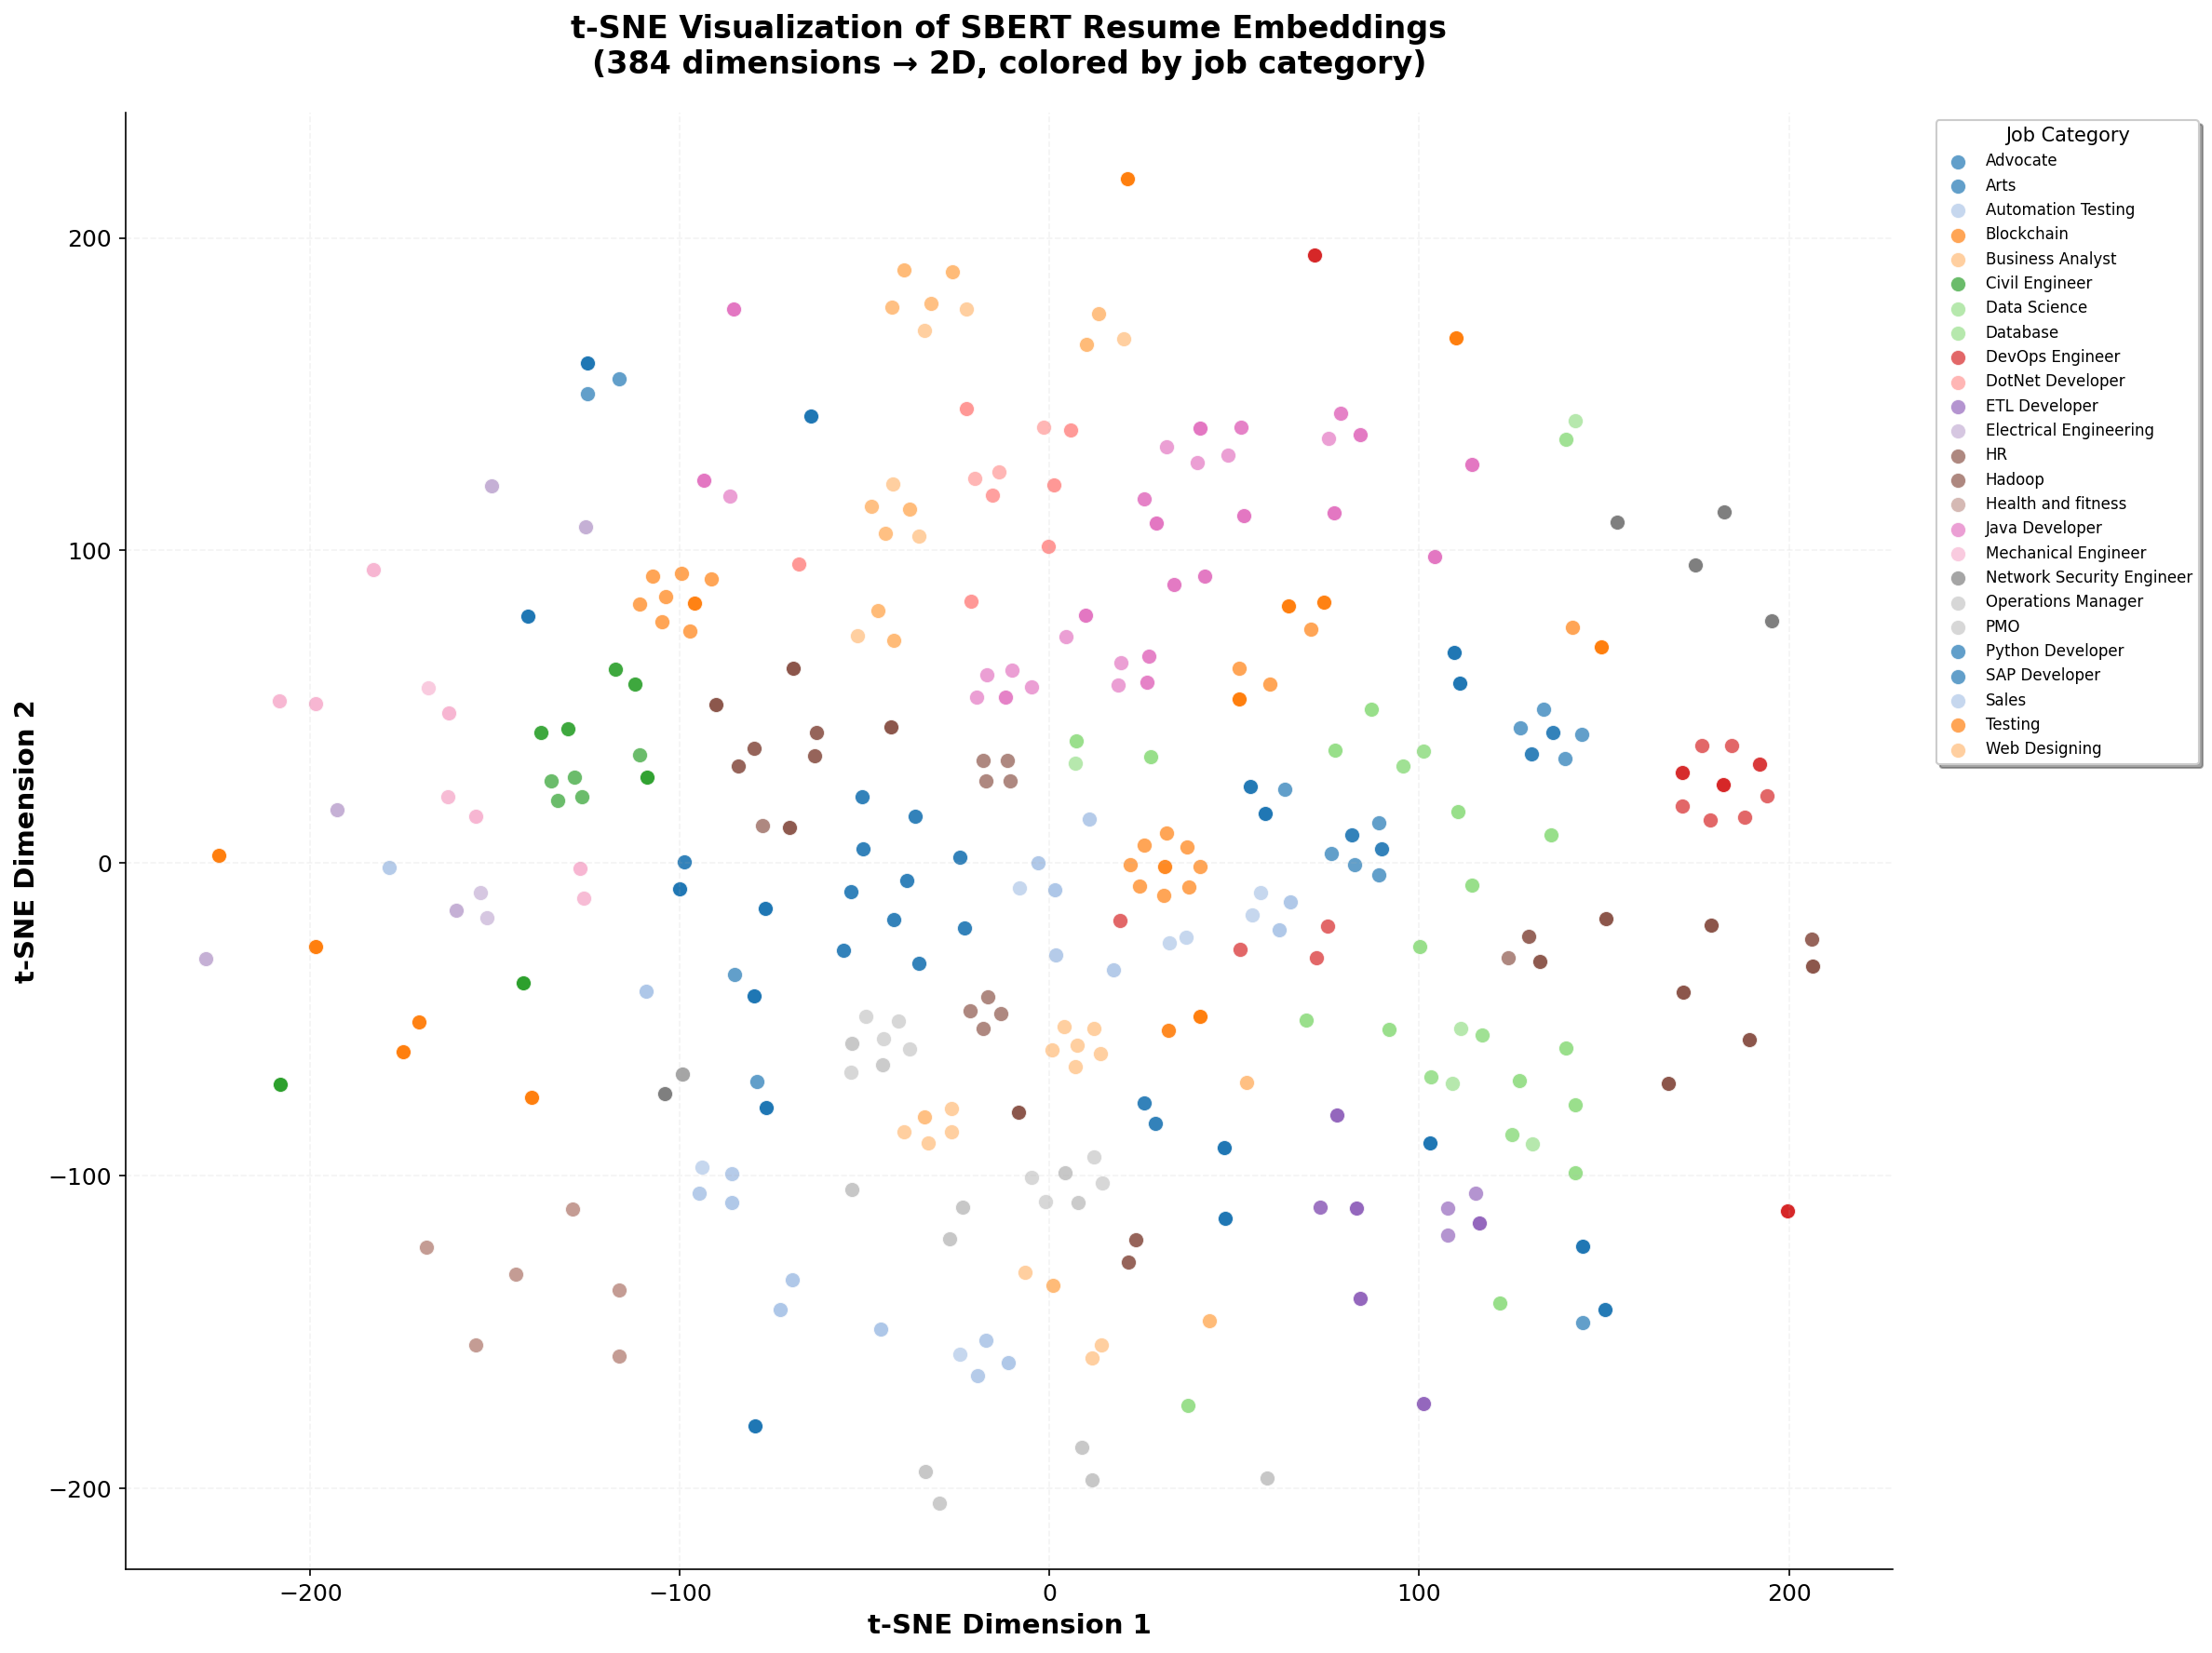

In [19]:
# ============================================================
# FIGURE 20: t-SNE SBERT Embeddings — IMPROVED
# ============================================================
from sklearn.manifold import TSNE

print("⏳ Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(sbert_embeddings)

fig, ax = plt.subplots(figsize=(16, 12))
categories = df_resumes['Category'].values
unique_cats = sorted(df_resumes['Category'].unique())
cmap = plt.cm.get_cmap('tab20', len(unique_cats))

for i, cat in enumerate(unique_cats):
    mask = categories == cat
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=[cmap(i % 20)], label=cat, s=60, alpha=0.7, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE Dimension 1', fontsize=14, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=14, fontweight='bold')
ax.set_title('t-SNE Visualization of SBERT Resume Embeddings\n(384 dimensions → 2D, colored by job category)',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8,
          frameon=True, fancybox=True, shadow=True, ncol=1,
          title='Job Category', title_fontsize=10)
ax.grid(alpha=0.15, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig(fig, 'fig_20_tsne_sbert_embeddings')
plt.show()

---
## 10. Job Description Preprocessing

Apply the same pipeline to job descriptions for resume-JD matching.

In [20]:
# ============================================================
# 10.1 Preprocess Job Descriptions
# ============================================================

# Find the description column
desc_col = None
for col in df_jd.columns:
    if 'description' in col.lower():
        desc_col = col
        break
if desc_col is None:
    text_cols = df_jd.select_dtypes(include='object').columns
    avg_lens = {col: df_jd[col].dropna().str.len().mean() for col in text_cols}
    desc_col = max(avg_lens, key=avg_lens.get)

print(f"Using JD column: '{desc_col}'")
print(f"Rows before cleaning: {len(df_jd):,}")

# Clean
df_jd['cleaned_jd'] = df_jd[desc_col].apply(clean_resume_text)
df_jd['normalized_jd'] = df_jd['cleaned_jd'].apply(normalize_text)

# Remove empty JDs
df_jd = df_jd[df_jd['cleaned_jd'].str.len() > 50].reset_index(drop=True)
print(f"Rows after cleaning:  {len(df_jd):,}")

# Extract skills from JDs
print("\n⏳ Extracting skills from job descriptions...")
df_jd['jd_skills'] = df_jd['cleaned_jd'].apply(
    lambda x: [s['skill'] for s in extract_skills_advanced(x, all_skills, skill_to_cat)]
)
df_jd['jd_skill_count'] = df_jd['jd_skills'].str.len()

print(f"\n✅ JD preprocessing complete!")
print(f"Average skills per JD: {df_jd['jd_skill_count'].mean():.1f}")

Using JD column: 'Job Description'
Rows before cleaning: 30,000
Rows after cleaning:  30,000

⏳ Extracting skills from job descriptions...

✅ JD preprocessing complete!
Average skills per JD: 0.2


In [21]:
# ============================================================
# 10.2 Generate SBERT Embeddings for JDs (sample)
# ============================================================

# Use a sample for embeddings (full dataset in training)
jd_sample = df_jd['cleaned_jd'].head(5000).tolist()
jd_sample_truncated = [text[:2000] for text in jd_sample]

print("⏳ Generating SBERT embeddings for JDs (5000 samples)...")
jd_embeddings = sbert_model.encode(
    jd_sample_truncated,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True
)

print(f"\n✅ JD embeddings: {jd_embeddings.shape}")

# Save
np.save(os.path.join(DATA_PROCESSED, 'jd_sbert_embeddings_sample.npy'), jd_embeddings)
print("💾 JD embeddings saved")

⏳ Generating SBERT embeddings for JDs (5000 samples)...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]


✅ JD embeddings: (5000, 384)
💾 JD embeddings saved


---
## 11. Compute Baseline Similarity Scores

Paper 8: *"A cosine similarity algorithm is employed to refine recommendations, matching the required skills of the jobs with the individual's skills."*

✅ Similarity matrix computed: (100, 100)

Similarity Statistics:
  Mean:   0.1481
  Std:    0.0812
  Min:    -0.0854
  Max:    0.4913
  Median: 0.1409
💾 Saved: fig_21_resume_jd_similarity_heatmap.png


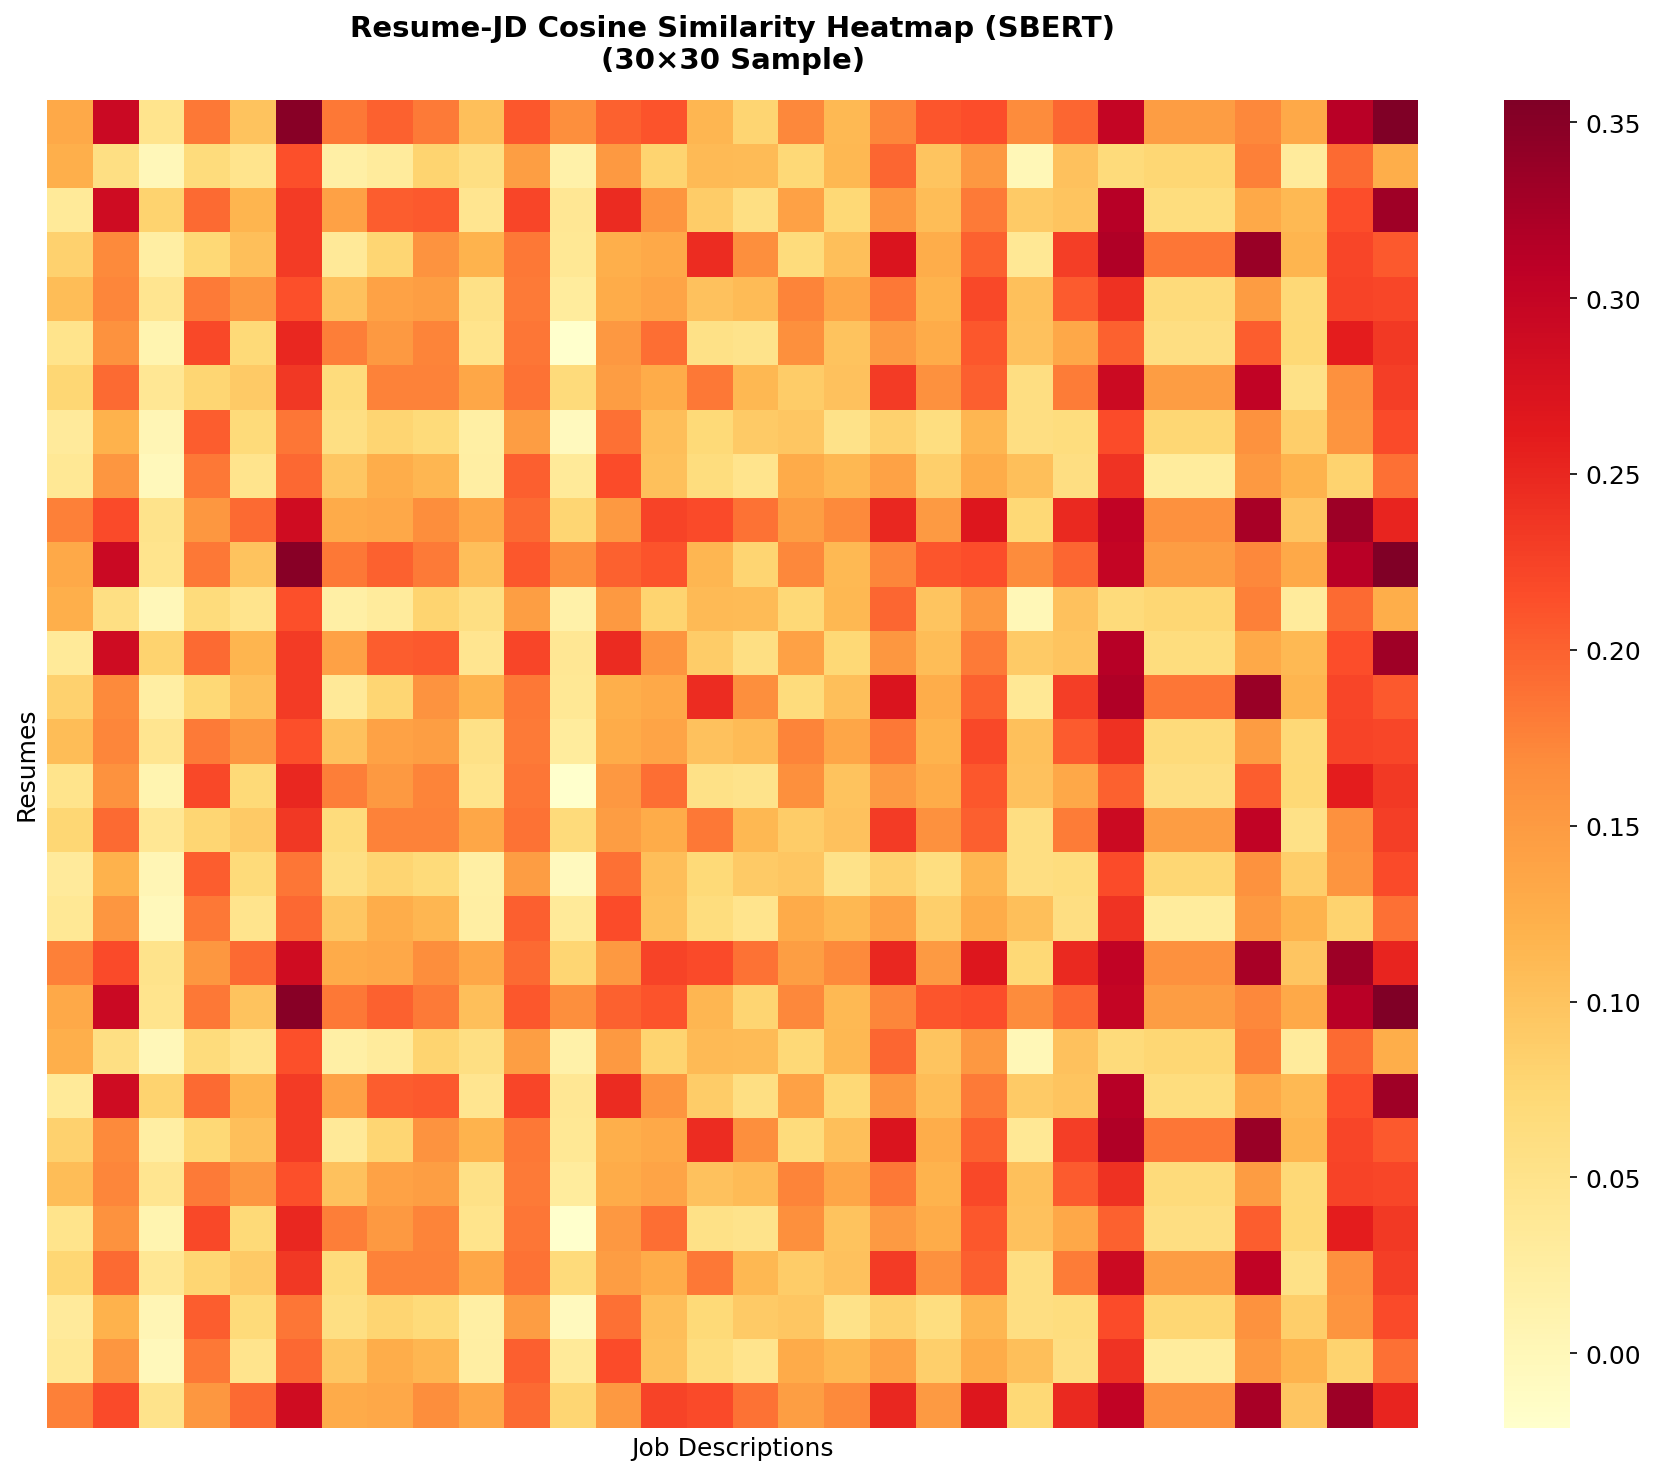

In [27]:
# ============================================================
# 11.1 Cosine Similarity Baselines
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity between first 100 resumes and first 100 JDs
n_sample = min(100, len(sbert_embeddings), len(jd_embeddings))

sim_matrix = cosine_similarity(sbert_embeddings[:n_sample], jd_embeddings[:n_sample])

print(f"✅ Similarity matrix computed: {sim_matrix.shape}")
print(f"\nSimilarity Statistics:")
print(f"  Mean:   {sim_matrix.mean():.4f}")
print(f"  Std:    {sim_matrix.std():.4f}")
print(f"  Min:    {sim_matrix.min():.4f}")
print(f"  Max:    {sim_matrix.max():.4f}")
print(f"  Median: {np.median(sim_matrix):.4f}")

# FIGURE: Similarity Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_matrix[:30, :30], cmap='YlOrRd', ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_title('Resume-JD Cosine Similarity Heatmap (SBERT)\n(30×30 Sample)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Job Descriptions', fontsize=12)
ax.set_ylabel('Resumes', fontsize=12)
plt.tight_layout()
save_fig(fig, 'fig_21_resume_jd_similarity_heatmap')
plt.show()

---
## 12. Save All Processed Data

In [28]:
# ============================================================
# 12.1 Save All Processed DataFrames
# ============================================================

# Save the fully processed resume dataframe
save_columns = [
    'Category', 'category_encoded', 'Resume', 'cleaned_text', 'normalized_text',
    'processed_text', 'clean_word_count', 'clean_char_count', 'token_count',
    'email', 'phone', 'linkedin', 'github',
    'highest_education', 'years_exp',
    'skills_list', 'skill_count', 'skill_categories',
    'section_education', 'section_experience', 'section_skills',
    'section_projects', 'section_summary', 'section_achievements',
]

# Keep only columns that exist
save_columns = [c for c in save_columns if c in df_resumes.columns]
df_processed = df_resumes[save_columns].copy()

# Convert lists to JSON strings for CSV storage
for col in ['skills_list', 'skill_categories']:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].apply(json.dumps)

df_processed.to_csv(os.path.join(DATA_PROCESSED, 'resumes_fully_processed.csv'), index=False)
print("✅ Saved: resumes_fully_processed.csv")

# Save JD processed data
jd_save_cols = [c for c in df_jd.columns if c in [
    desc_col, 'cleaned_jd', 'normalized_jd', 'jd_skills', 'jd_skill_count'
] + [c for c in df_jd.columns if 'title' in c.lower()]]

df_jd_save = df_jd[jd_save_cols].copy()
if 'jd_skills' in df_jd_save.columns:
    df_jd_save['jd_skills'] = df_jd_save['jd_skills'].apply(json.dumps)
df_jd_save.to_csv(os.path.join(DATA_PROCESSED, 'jd_processed.csv'), index=False)
print("✅ Saved: jd_processed.csv")

# Save train/val/test indices
split_data = {
    'train_idx': X_train.index.tolist(),
    'val_idx': X_val.index.tolist(),
    'test_idx': X_test.index.tolist(),
}
with open(os.path.join(DATA_PROCESSED, 'data_splits.json'), 'w') as f:
    json.dump(split_data, f)
print("✅ Saved: data_splits.json")

# Summary of all saved files
print(f"\n{'='*60}")
print(f"📁 ALL PROCESSED FILES:")
print(f"{'='*60}")
for f in sorted(glob.glob(os.path.join(DATA_PROCESSED, "*"))):
    if os.path.isfile(f):
        size = os.path.getsize(f) / (1024*1024)
        print(f"  📄 {os.path.basename(f):40s} {size:>8.2f} MB")

✅ Saved: resumes_fully_processed.csv
✅ Saved: jd_processed.csv


AttributeError: 'csr_matrix' object has no attribute 'index'

---
## ✅ Notebook 03 Complete!

### What we accomplished:
1. ✅ **Text Cleaning** — HTML removal, URL/email/phone extraction, normalization
2. ✅ **Regex Entity Extraction** — emails, phones, education, experience, LinkedIn/GitHub
3. ✅ **Resume Section Segmentation** — education, experience, skills, projects, summary
4. ✅ **Advanced Skill Extraction** — 200+ skills with categories and context
5. ✅ **Tokenization & Lemmatization** — NLTK-based with custom stopwords
6. ✅ **TF-IDF Vectorization** — 5,000 features, bigrams, sublinear scaling
7. ✅ **SBERT Embeddings** — 384-dim dense vectors for semantic matching
8. ✅ **Label Encoding** — 25 categories encoded for classification
9. ✅ **Data Splitting** — 80/10/10 stratified train/val/test
10. ✅ **Baseline Similarity** — Cosine similarity between resume-JD pairs
11. ✅ **JD Preprocessing** — Same pipeline applied to job descriptions

### Figures Generated:
| # | Figure | For Thesis |
|---|--------|------------|
| 18 | Avg Skills Per Category | Ch 4 |
| 19 | TF-IDF Features by Category | Ch 4 |
| 20 | t-SNE SBERT Embeddings | Ch 4 (Key figure!) |
| 21 | Resume-JD Similarity Heatmap | Ch 4 |

### Saved Artifacts:
- `resumes_fully_processed.csv` — Complete processed resume dataset
- `jd_processed.csv` — Processed job descriptions
- `sbert_embeddings.npy` — 384-dim SBERT embeddings for all resumes
- `tfidf_vectorizer.pkl` — Fitted TF-IDF vectorizer
- `label_encoder.pkl` — Category label encoder
- `data_splits.json` — Train/val/test indices

### Next → Notebook 04: Feature Engineering & Model Preparation
- Word2Vec training (Paper 8 methodology)
- Combine TF-IDF + SBERT + handcrafted features
- Prepare data tensors for BiLSTM training
- Build feature matrices for the multi-task scoring model

---
*"NLP preprocessing is the foundation — garbage in, garbage out. But clean data in, deep learning magic out!"* 🔬🚀